# Amazon Electronics Sales Analysis

## Objective

The objective of this project is to analyze Amazon Electronics sales and customer ratings using Python. The project focuses on cleaning the dataset, exploring customer behavior, identifying trends, and generating business insights through data visualization.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib

### Dataset
Amazon Electronics Dataset (Kaggle)

1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
plt.style.use('ggplot')

2. Load Dataset

In [3]:
df = pd.read_csv("electronics.csv")

3. Dataset Overview

In [4]:
df.head()

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999.0,NaN,0.0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999.0,NaN,0.0
2,0,2,3.0,1999-06-17,Female,Portable Audio & Video,NaN,1999.0,NaN,0.0
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999.0,NaN,0.0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999.0,NaN,0.0


In [5]:
df.shape

(164525, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164525 entries, 0 to 164524
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   item_id     164525 non-null  int64  
 1   user_id     164525 non-null  int64  
 2   rating      164525 non-null  float64
 3   timestamp   164525 non-null  object 
 4   model_attr  164524 non-null  object 
 5   category    164524 non-null  object 
 6   brand       66011 non-null   object 
 7   year        164524 non-null  float64
 8   user_attr   17640 non-null   object 
 9   split       164524 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 12.6+ MB


In [7]:
df.isnull().sum()

,0
item_id,0
user_id,0
rating,0
timestamp,0
model_attr,1
category,1
brand,98514
year,1
user_attr,146885
split,1


4. Data Cleaning

Exploratory Data Analysis

    • Customer Rating Distribution
    • Product Categories
    • Top Brands
    • Reviews Over Time
    • Category-wise Ratings

In [8]:
# Remove the user_attr column
df = df.drop(columns=['user_attr'])

In [9]:
# Replace missing brand names with "Unknown"
df['brand'] = df['brand'].fillna('Unknown')

In [10]:
# Remove the few rows with missing values
df = df.dropna()

In [11]:
# Check that the data is clean
df.isnull().sum()

,0
item_id,0
user_id,0
rating,0
timestamp,0
model_attr,0
category,0
brand,0
year,0
split,0


In [12]:
df.to_csv("cleaned_amazon_electronics.csv", index=False)

Saved the cleaned dataset

##Key Business Insights

## CHART 1

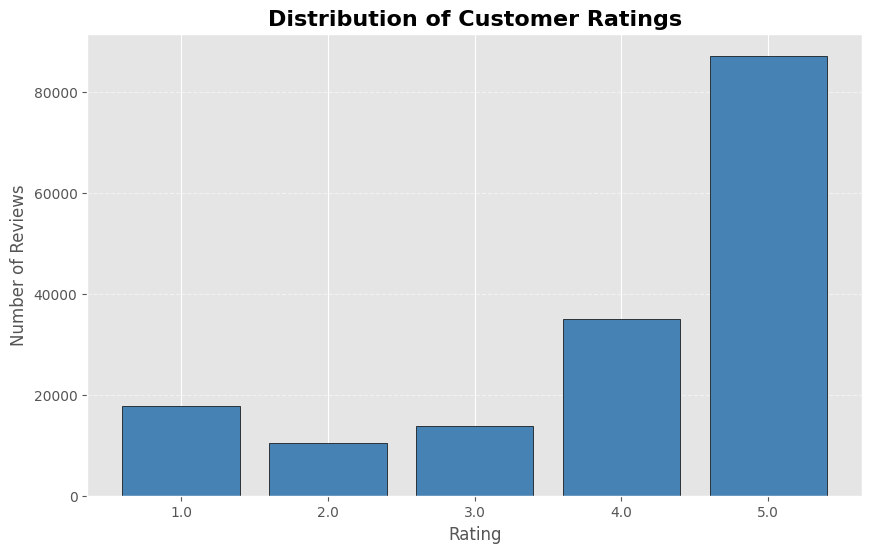

In [23]:
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(10,6))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribution of Customer Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## CHART 2

## Top 10 Product Categories

### Objective
Identify the product categories that receive the highest number of customer reviews.

### Why it matters
Understanding which categories receive the most customer engagement helps identify popular product segments and market demand.

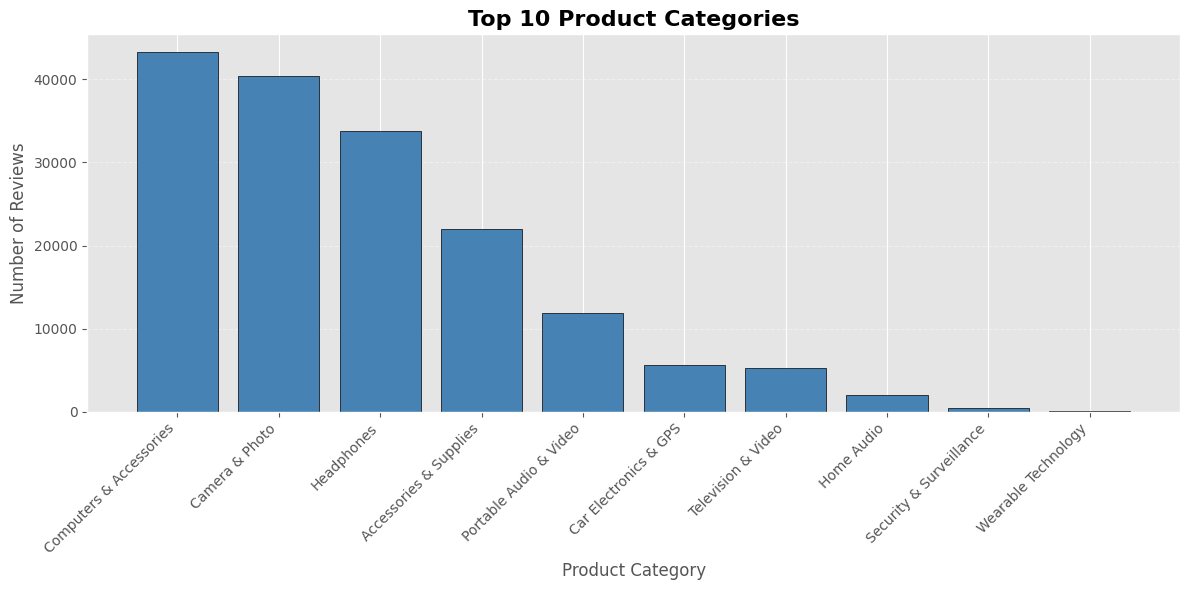

In [22]:
# Count reviews for each category
category_counts = df['category'].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.bar(
    category_counts.index,
    category_counts.values,
    color='steelblue',
    edgecolor='black'
)

plt.title("Top 10 Product Categories", fontsize=16, fontweight='bold')
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### Insight

The chart highlights the ten product categories with the highest number of customer reviews. Categories with more reviews generally indicate higher customer engagement and stronger market demand.

## CHART 3

## Top 10 Brands

### Objective
Identify the brands that appear most frequently in the dataset.

### Why it matters
This analysis highlights the brands with the greatest customer presence and helps identify the most recognized manufacturers in the electronics market.

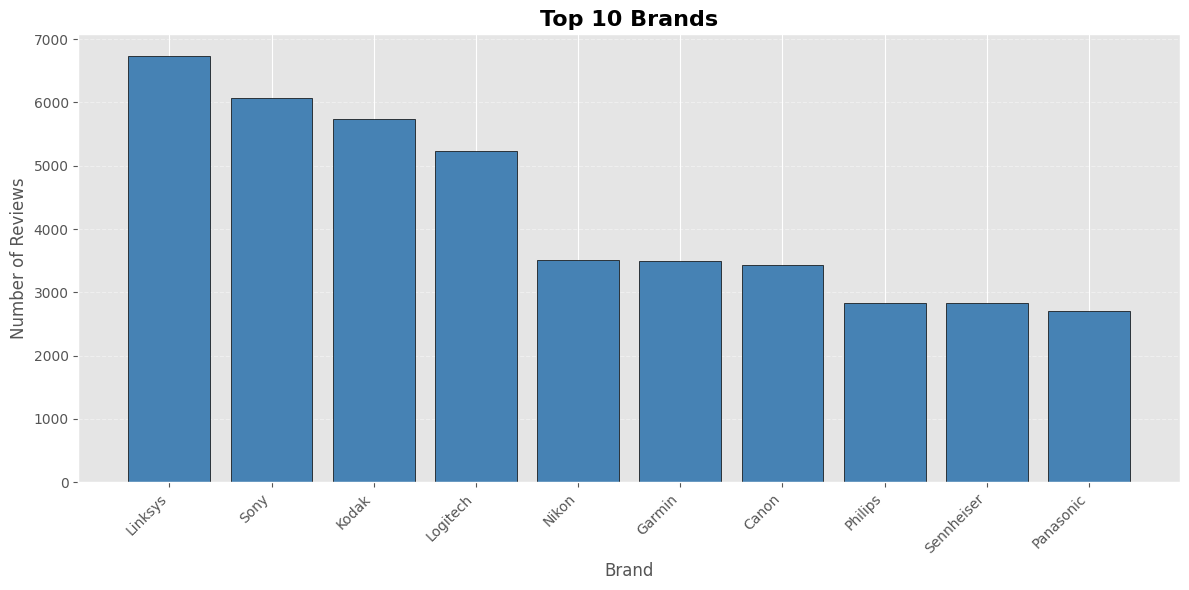

In [24]:
# Count the top 10 brands
brand_counts = df[df['brand'] != 'Unknown']['brand'].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.bar(
    brand_counts.index,
    brand_counts.values,
    color='steelblue',
    edgecolor='black'
)

plt.title("Top 10 Brands", fontsize=16, fontweight='bold')
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### Insight

The chart shows the ten most frequently reviewed brands in the dataset. Higher review counts suggest stronger customer engagement and greater market presence for these brands.

## CHART 4

## Customer Reviews Over Time

### Objective
Analyze how customer reviews are distributed across different years.

### Why it matters
Review trends over time can reveal changes in customer activity, product popularity, and market growth.

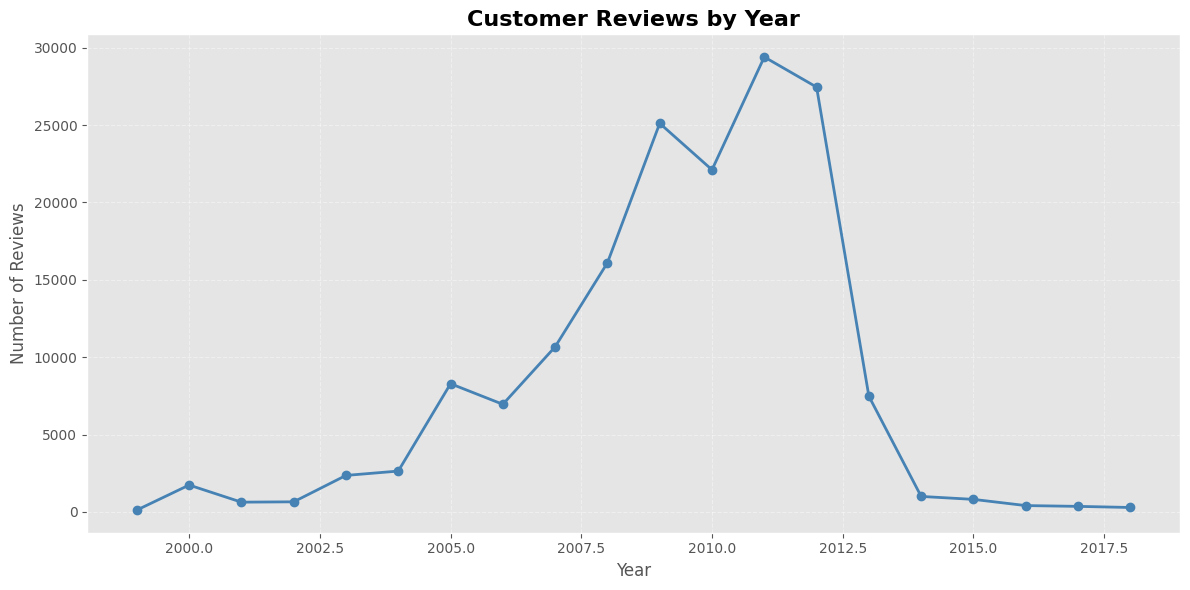

In [25]:
reviews_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    reviews_per_year.index,
    reviews_per_year.values,
    marker='o',
    linewidth=2,
    color='steelblue'
)

plt.title("Customer Reviews by Year", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### Insight

The trend illustrates how customer review activity has changed over the years, providing insight into periods of increased customer engagement.

## CHART 5

## Average Rating by Product Category

### Objective
Compare the average customer rating across different product categories.

### Why it matters
This analysis helps identify which product categories receive the highest customer satisfaction based on average ratings.

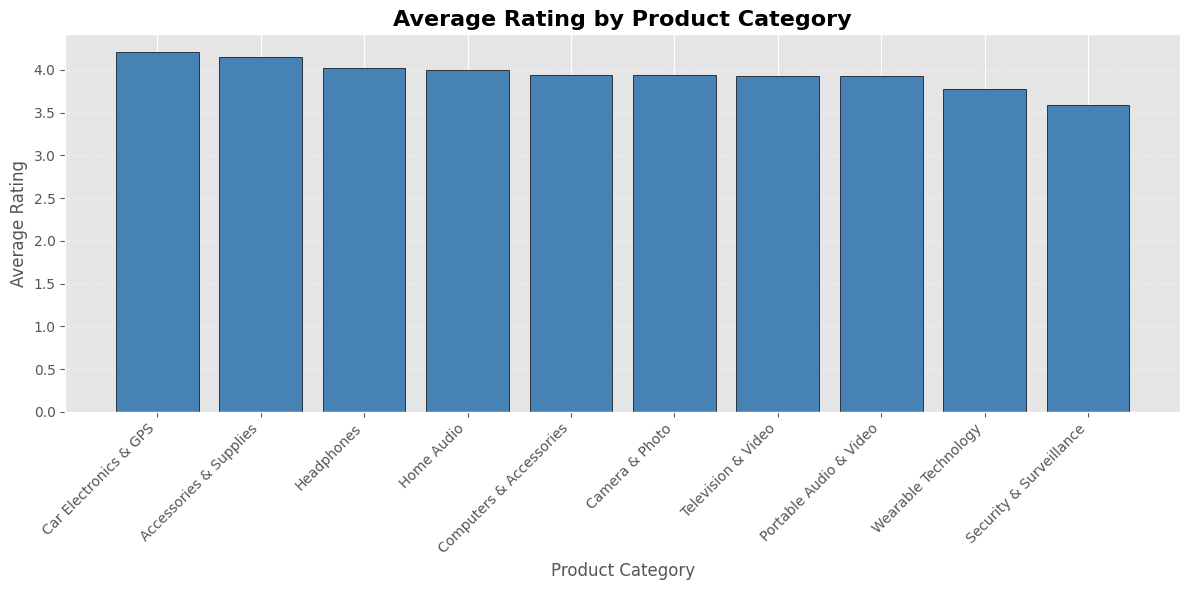

In [26]:
# Calculate average rating for each category
avg_rating = (
    df.groupby('category')['rating']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    avg_rating.index,
    avg_rating.values,
    color='steelblue',
    edgecolor='black'
)

plt.title("Average Rating by Product Category", fontsize=16, fontweight='bold')
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### Insight

This chart compares the average customer rating across product categories. Categories with higher average ratings indicate greater customer satisfaction, while lower-rated categories may require further investigation to understand customer concerns.